# Trabajo Practico Nº2 - PDI (Grupo 6)
Integrantes: Añaños Diego, Quinteros Facundo, Lasarte Roberto

# 0. Importaciónes de Librerias a Usar

In [1]:
import os
import cv2
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Detección y clasificación de pastillas

### A. Segmentar el área de la cinta transportadora (ROI) en donde se encuentran las pastillas.

In [2]:
def imshow(img, new_fig=True, title=None, color_img=False, blocking=False, colorbar=False, ticks=False):
  if new_fig:
    plt.figure()
  if color_img:
    plt.imshow(img)
  else:
    plt.imshow(img, cmap='gray')
  plt.title(title)
  if not ticks:
    plt.xticks([]), plt.yticks([])
  if colorbar:
    plt.colorbar()
  if new_fig:
    plt.show(block=blocking)

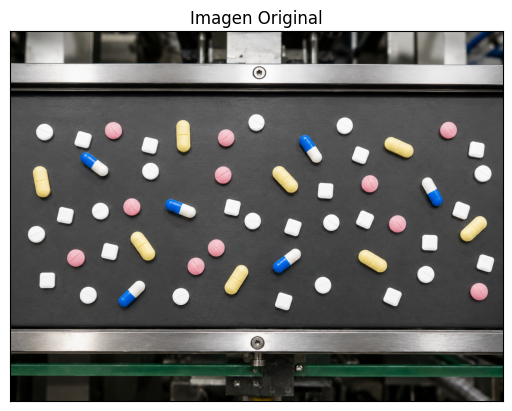

In [3]:
pastillas = cv2.imread("pills.png")
pastillas_RGB = cv2.cvtColor(pastillas, cv2.COLOR_BGR2RGB)
imshow(pastillas_RGB, title="Imagen Original", color_img=True)

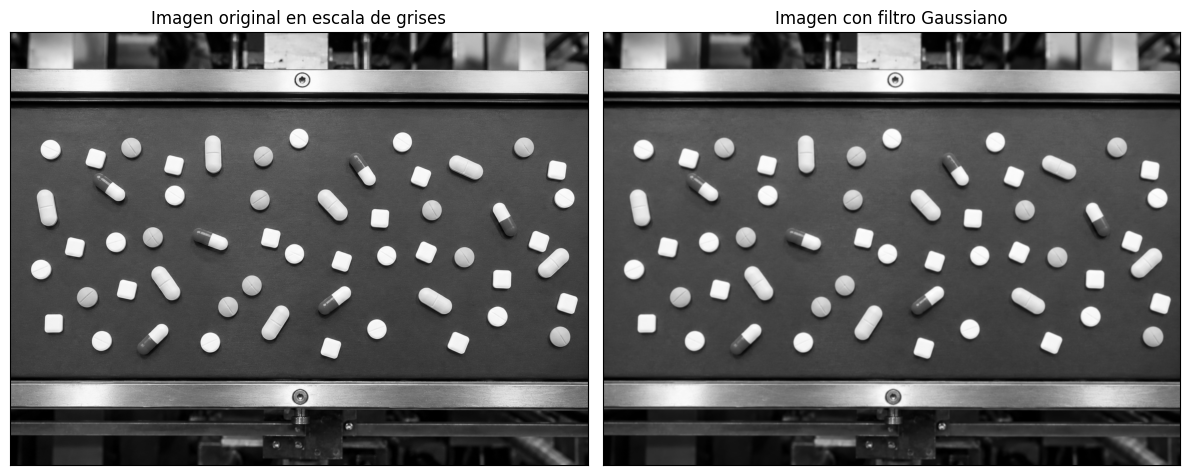

In [4]:
pastillas_gris = cv2.imread('pills.png', cv2.IMREAD_GRAYSCALE)
blur = cv2.GaussianBlur(pastillas_gris, (5, 5), 0)

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
imshow(pastillas_gris, new_fig = False, title = 'Imagen original en escala de grises', color_img = False)
plt.subplot(1, 2, 2)
imshow(blur, new_fig = False, title = 'Imagen con filtro Gaussiano', color_img = False)

plt.tight_layout()
plt.show()

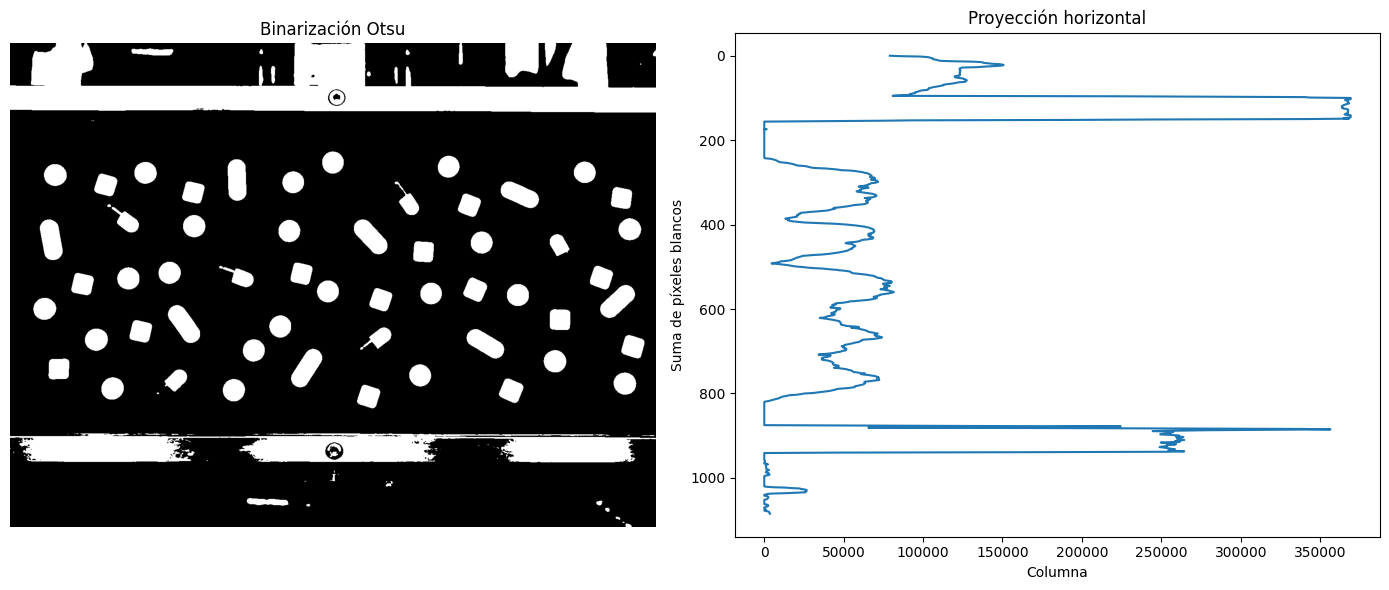

In [5]:
_, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
horizontal_projection = np.sum(mask, axis = 1)

plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap = 'gray')
plt.title('Binarización Otsu')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.plot(horizontal_projection, np.arange(len(horizontal_projection)))
plt.gca().invert_yaxis()
plt.title('Proyección horizontal')
plt.xlabel('Columna')
plt.ylabel('Suma de píxeles blancos')

plt.tight_layout()
plt.show()

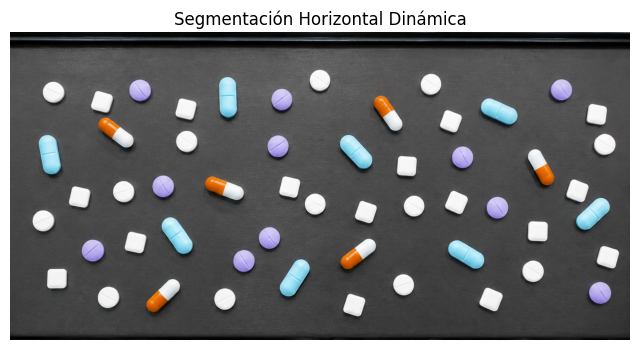

In [6]:
# Se divide el vector a la mitad para aislar el pico izquierdo del derecho
mitad = len(horizontal_projection) // 2

# Se encuentra la posición exacta (índice) de los dos picos más altos
pico_izquierdo = np.argmax(horizontal_projection[:mitad])
pico_derecho = np.argmax(horizontal_projection[mitad:]) + mitad

# Se define un umbral adaptativo basado en la altura de los picos
# Si el pico mide 350.000, el 5% es 17.500. Todo lo que esté abajo es piso/valle.
umbral_corte = 0.05 * horizontal_projection[pico_izquierdo]

# Se busca el corte superior avanzando a la derecha desde el primer pico
# hasta que la señal caiga por debajo del umbral (fin de la barra)
indices_despues_pico1 = np.where(horizontal_projection[pico_izquierdo:] < umbral_corte)[0]
corte_superior = pico_izquierdo + indices_despues_pico1[0]

# Se busca el corte inferior retrocediendo a la izquierda desde el segundo pico
# hasta que la señal caiga por debajo del umbral (inicio de la barra)
indices_antes_pico2 = np.where(horizontal_projection[:pico_derecho] < umbral_corte)[0]
corte_inferior = indices_antes_pico2[-1]

# Se realiza el recorte final limpio de la imagen original usando los cortes detectados
pastillas_ROI = pastillas[corte_superior:corte_inferior, :]

plt.figure(figsize = (8, 8))
plt.imshow(pastillas_ROI, cmap = 'gray')
plt.title('Segmentación Horizontal Dinámica')
plt.axis('off')
plt.show()

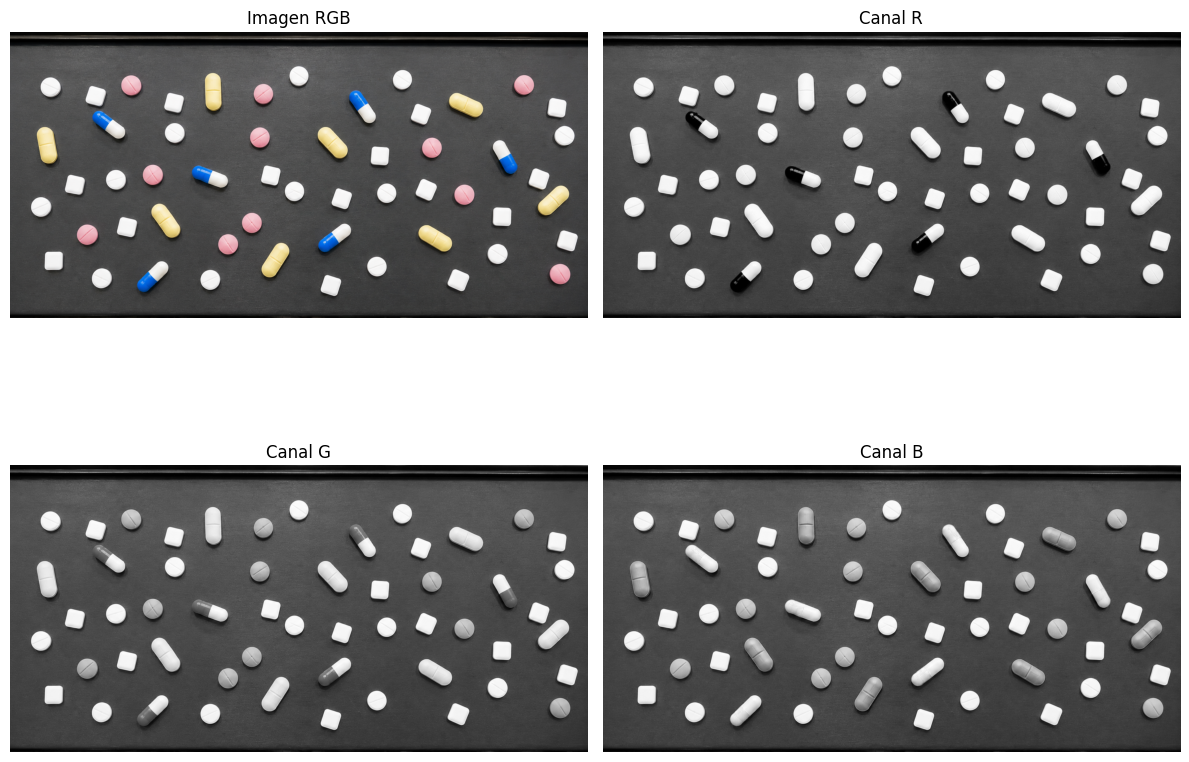

In [7]:
pastillas_ROI_RGB = cv2.cvtColor(pastillas_ROI, cv2.COLOR_BGR2RGB)
B, G, R = cv2.split(pastillas_ROI)

fig, axs = plt.subplots(2, 2, figsize = (12, 10))
axs = axs.ravel()
titles = ["Imagen RGB", "Canal R", "Canal G", "Canal B"]
imagenes = [pastillas_ROI_RGB, R, G, B]
for idx, (ax, img, title) in enumerate(zip(axs, imagenes, titles)):
  if idx == 0:
    ax.imshow(img)
  else:
    ax.imshow(img, cmap = "gray")
  ax.set_title(title)
  ax.axis("off")
plt.tight_layout()
plt.show()

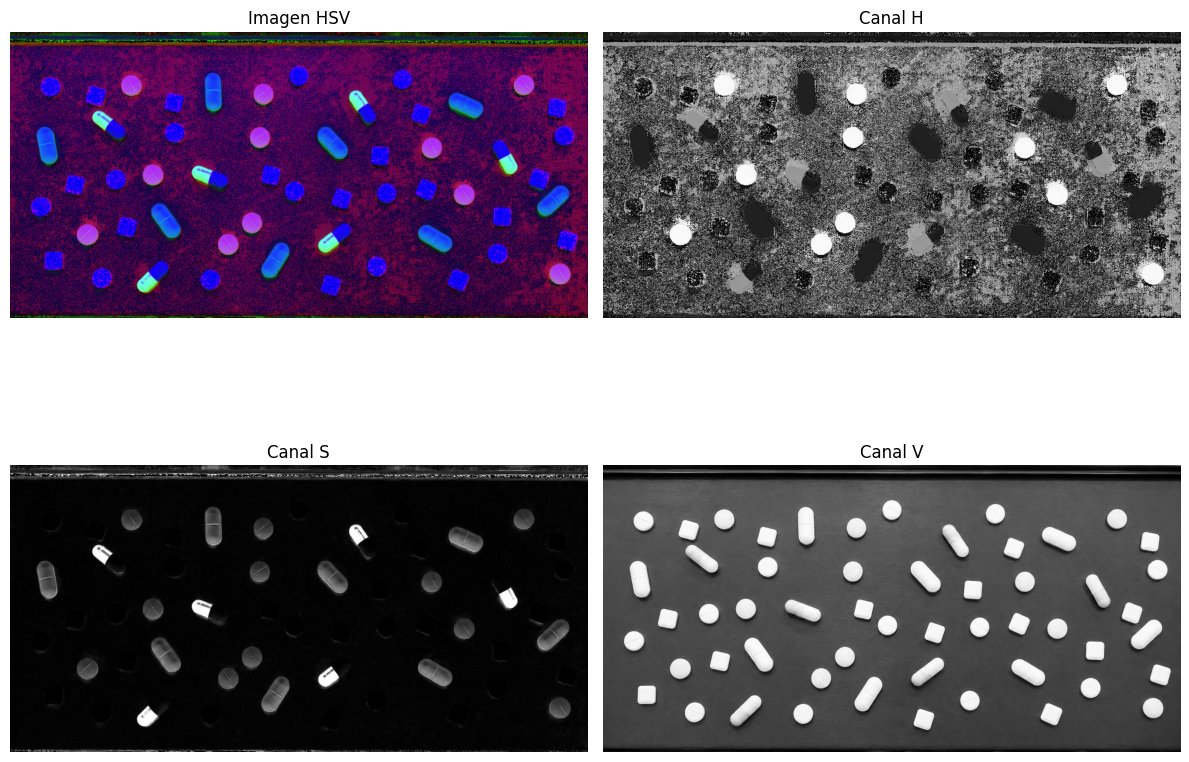

In [8]:
pastillas_ROI_HSV = cv2.cvtColor(pastillas_ROI, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(pastillas_ROI_HSV)

fig, axs = plt.subplots(2, 2, figsize = (12, 10))
axs = axs.ravel()
titles = ["Imagen HSV", "Canal H", "Canal S", "Canal V"]
imagenes = [pastillas_ROI_HSV, H, S, V]
for idx, (ax, img, title) in enumerate(zip(axs, imagenes, titles)):
  if idx == 0:
    ax.imshow(img)
  else:
    ax.imshow(img, cmap = "gray")
  ax.set_title(title)
  ax.axis("off")
plt.tight_layout()
plt.show()

### B. Detectar y segmentar individualmente cada una de las pastillas presentes.

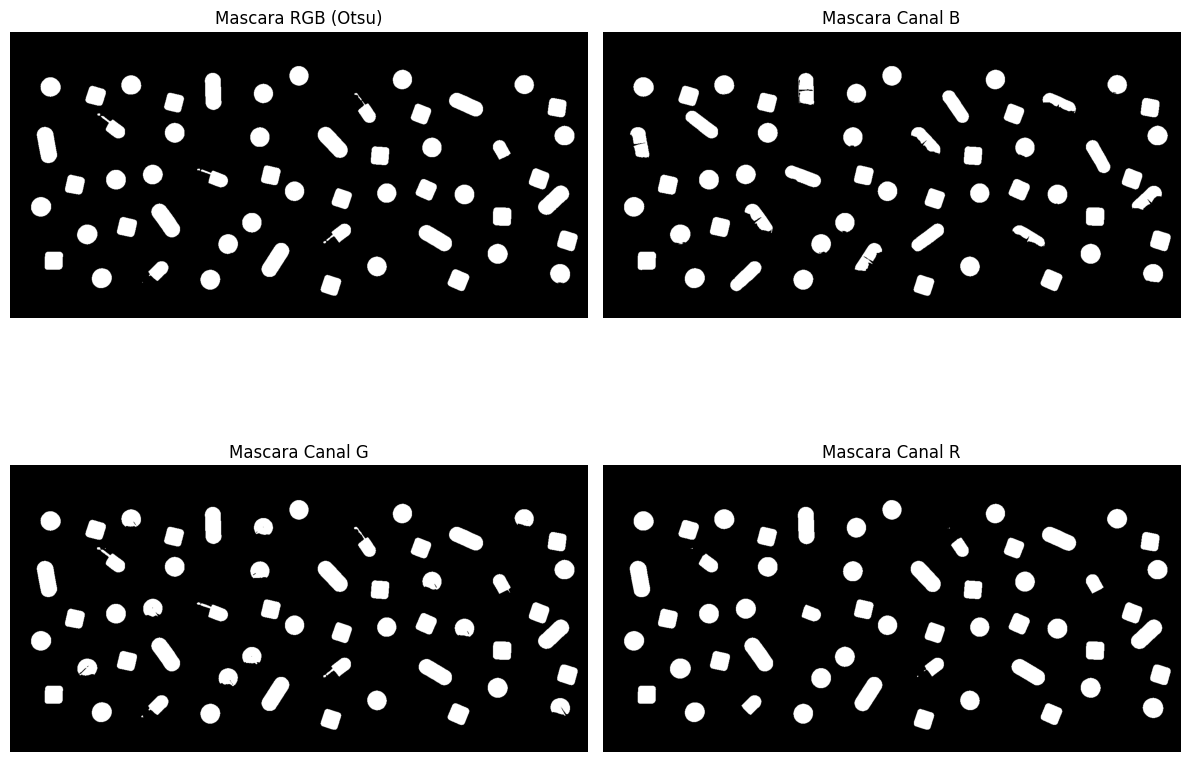

In [9]:
pastillas_ROI_RGB_gris = cv2.cvtColor(pastillas_ROI_RGB, cv2.COLOR_RGB2GRAY)
pastillas_ROI_RGB_gris_blur = cv2.GaussianBlur(pastillas_ROI_RGB_gris, ksize = (3, 3), sigmaX = 1.5)
_, mask_ROI_RGB = cv2.threshold(pastillas_ROI_RGB_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_B_gris_blur = cv2.GaussianBlur(B, ksize = (3, 3), sigmaX = 1.5)
_, mask_ROI_B = cv2.threshold(pastillas_ROI_B_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_G_gris_blur = cv2.GaussianBlur(G, ksize = (3, 3), sigmaX = 1.5)
_, mask_ROI_G = cv2.threshold(pastillas_ROI_G_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_R_gris_blur = cv2.GaussianBlur(R, ksize = (3, 3), sigmaX = 1.5)
_, mask_ROI_R = cv2.threshold(pastillas_ROI_R_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axs = plt.subplots(2, 2, figsize = (12, 10))
axs = axs.ravel()
titles = ["Mascara RGB (Otsu)", "Mascara Canal B", "Mascara Canal G", "Mascara Canal R"]
masks = [mask_ROI_RGB, mask_ROI_B, mask_ROI_G, mask_ROI_R]

for ax, mask_img, title in zip(axs, masks, titles):
  ax.imshow(mask_img, cmap = 'gray')
  ax.set_title(title)
  ax.axis('off')

plt.tight_layout()
plt.show()

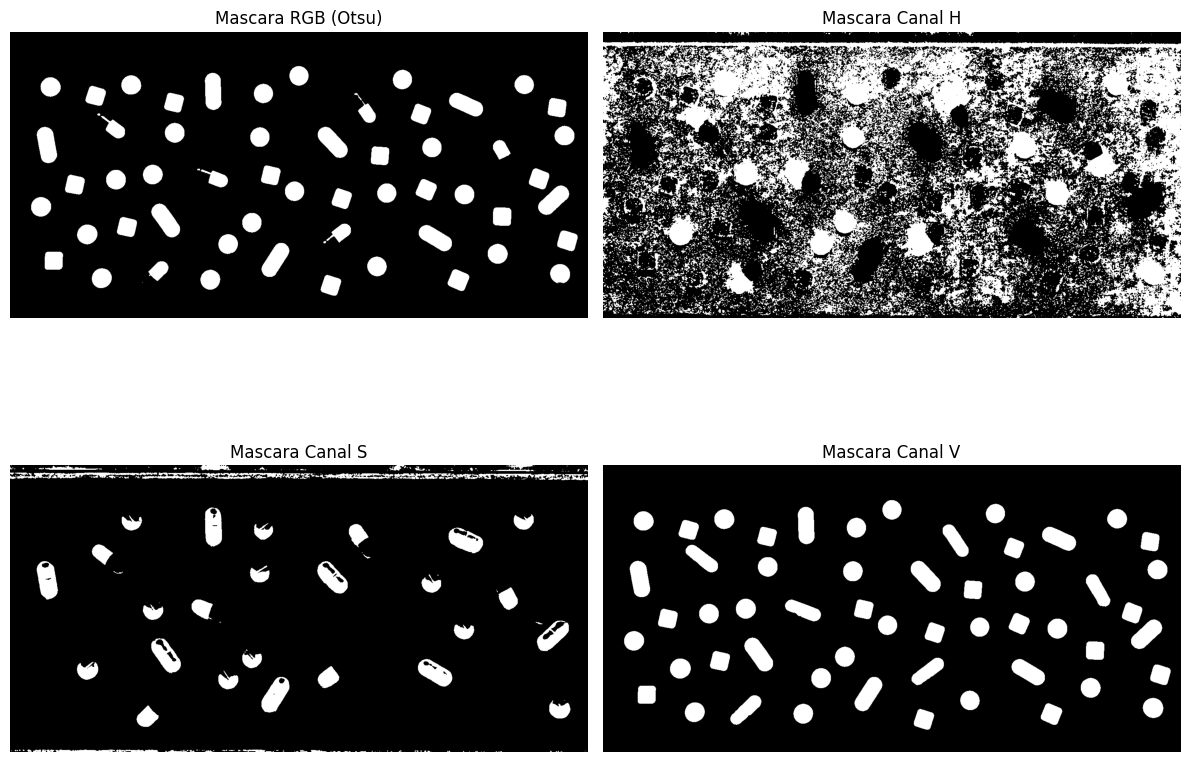

In [10]:
pastillas_ROI_H_gris_blur = cv2.GaussianBlur(H, ksize = (3, 3), sigmaX = 1.5)
_, mask_ROI_H = cv2.threshold(pastillas_ROI_H_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_S_gris_blur = cv2.GaussianBlur(S, ksize = (3, 3), sigmaX = 1.5)
_, mask_ROI_S = cv2.threshold(pastillas_ROI_S_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pastillas_ROI_V_gris_blur = cv2.GaussianBlur(V, ksize = (3, 3), sigmaX = 1.5)
_, mask_ROI_V = cv2.threshold(pastillas_ROI_V_gris_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axs = plt.subplots(2, 2, figsize = (12, 10))
axs = axs.ravel()
titles = ["Mascara RGB (Otsu)", "Mascara Canal H", "Mascara Canal S", "Mascara Canal V"]
masks = [mask_ROI_RGB, mask_ROI_H, mask_ROI_S, mask_ROI_V]

for ax, mask_img, title in zip(axs, masks, titles):
  ax.imshow(mask_img, cmap = 'gray')
  ax.set_title(title)
  ax.axis('off')

plt.tight_layout()
plt.show()

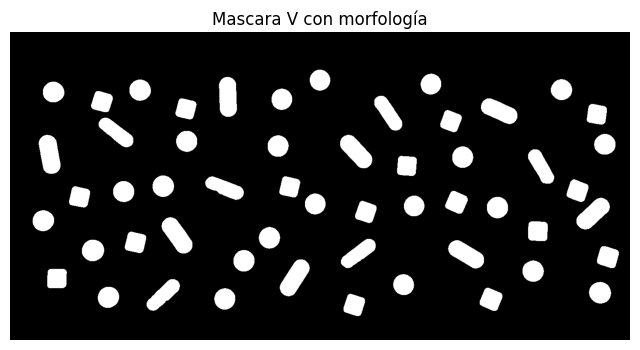

In [11]:
kernel = np.ones((3, 3), np.uint8)

mask_final = cv2.morphologyEx(mask_ROI_V, cv2.MORPH_CLOSE, kernel)
mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_OPEN, kernel)
plt.figure(figsize = (8, 8))
plt.imshow(mask_final, cmap = 'gray')
plt.title('Mascara V con morfología')
plt.axis('off')
plt.show()

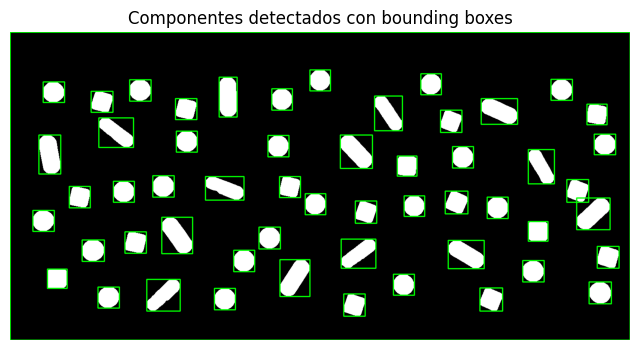

In [12]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_final, connectivity = 8)

mask_clean_color = cv2.cvtColor(mask_final, cv2.COLOR_GRAY2BGR)
for st in stats:
  cv2.rectangle(mask_clean_color, (st[0], st[1]), (st[0] + st[2], st[1] + st[3]), color = (0,255,0), thickness = 2)

plt.figure(figsize = (8, 8))
plt.imshow(cv2.cvtColor(mask_clean_color, cv2.COLOR_BGR2RGB))
plt.title('Componentes detectados con bounding boxes')
plt.axis('off')
plt.show()

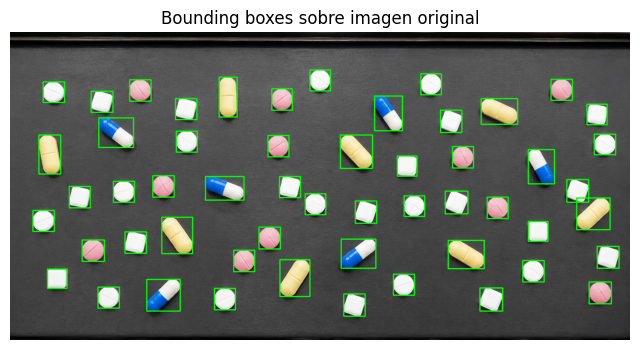

Número de pastillas: 54


In [13]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_final, connectivity = 8)

img_boxes = pastillas_ROI_RGB.copy()

for st in stats[1:]:
  x, y, w, h, area = st
  cv2.rectangle(img_boxes, (x, y), (x + w, y + h), color = (0, 255, 0), thickness = 2)

plt.figure(figsize = (8, 8))
plt.imshow(img_boxes)
plt.title('Bounding boxes sobre imagen original')
plt.axis('off')
plt.show()

print(f"Número de pastillas: {num_labels - 1}")

### C. Clasificar los distintos tipos de pastillas y realizar un conteo total de cada tipo.

In [14]:
imagenes_separadas = []
for i in range(1, num_labels):
  obj = (labels == i).astype(np.uint8)
  imagenes_separadas.append(obj)

pastillas_redondas = []
pastillas_cuadradas = []
pastillas_ovaladas = []

for img_individual in imagenes_separadas:
  contornos, _ = cv2.findContours(img_individual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if not contornos:
    continue
  cnt = contornos[0]
  area_real = cv2.contourArea(cnt)
  if area_real == 0:
    continue

  # Se obtiene el Bounding Box Rotado Real (Detecta pastillas alargadas independientemente de su orientación)
  rect_rotado = cv2.minAreaRect(cnt)
  (_, _), (ancho, alto), _ = rect_rotado # (centro_x, centro_y), (ancho, alto), angulo_rotacion
  if ancho == 0 or alto == 0:
    continue
  largo = max(ancho, alto)
  ancho_corto = min(ancho, alto)
  relacion_forma = largo / ancho_corto
  # Si es notablemente más larga que ancha, es OVALADA
  if relacion_forma > 1.35:
    pastillas_ovaladas.append(img_individual)
    continue

  # Se clasifica lo que queda (Círculos y Cuadrados)
  area_caja_rotada = largo * ancho_corto
  ocupacion = area_real / area_caja_rotada
  # Un círculo ocupa ~0.78 de su caja, un cuadrado ocupa ~0.92
  if ocupacion > 0.85:
    pastillas_cuadradas.append(img_individual)
  else:
    pastillas_redondas.append(img_individual)

  ## Factor de Forma - con contorno suavizado para reducir ruido 
  ## (Más escalable que el método de relación de aspecto + ocupación, pero más sensible a ruido)
  #epsilon = 0.005 * cv2.arcLength(cnt, True)
  #cnt_suave = cv2.approxPolyDP(cnt, epsilon, True)
  
  #perimetro = cv2.arcLength(cnt_suave, True)
  #if perimetro == 0:
  #  continue
  #factor_forma = area_real / (perimetro ** 2)

  #if factor_forma > 0.074:
  #  pastillas_redondas.append(img_individual)
  #else:
  #  pastillas_cuadradas.append(img_individual)

print(f"Redondas: {len(pastillas_redondas)} - Cantidad real: 24")
print(f"Cuadradas: {len(pastillas_cuadradas)} - Cantidad real: 16")
print(f"Ovaladas: {len(pastillas_ovaladas)} - Cantidad real: 14")

Redondas: 24 - Cantidad real: 24
Cuadradas: 16 - Cantidad real: 16
Ovaladas: 14 - Cantidad real: 14


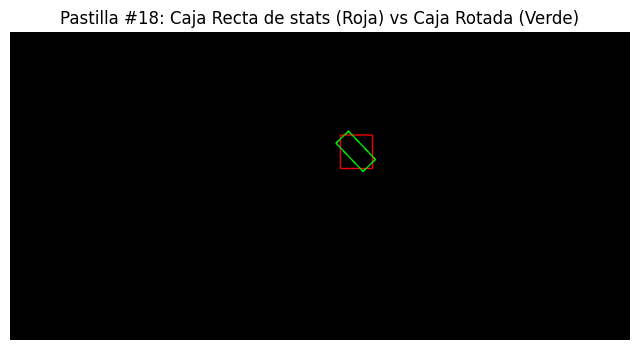

Caja Recta (Roja): Ancho = 75 px, Alto = 78 px
Relación de aspecto (Caja Recta): 1.04
----------------------------------------
Caja Rotada (Verde): Lado A = 40.3 px, Lado B = 91.4 px
Relación de aspecto (Caja Rotada Real): 2.27


In [15]:
# Ejemplo de visualización de una pastilla ovalada con minAreaRect
img_individual = imagenes_separadas[18]
imagen_color = cv2.cvtColor(img_individual, cv2.COLOR_GRAY2BGR)
# Caja Recta color ROJO
x, y, w, h = cv2.boundingRect(img_individual)
cv2.rectangle(imagen_color, (x, y), (x + w, y + h), (0, 0, 255), 2)

# Caja Rotada color VERDE
contornos, _ = cv2.findContours(img_individual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = contornos[0]
rect_rotado = cv2.minAreaRect(cnt)
esquinas_caja = cv2.boxPoints(rect_rotado) # Convertir las propiedades del rectángulo rotado a 4 coordenadas (esquinas) para dibujarlo
esquinas_caja = np.int64(esquinas_caja)
cv2.drawContours(imagen_color, [esquinas_caja], 0, (0, 255, 0), 2)

plt.figure(figsize = (8, 8))
plt.imshow(cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB))
plt.title(f"Pastilla #18: Caja Recta de stats (Roja) vs Caja Rotada (Verde)")
plt.axis("off")
plt.show()

print(f"Caja Recta (Roja): Ancho = {w} px, Alto = {h} px")
relacion_recta = max(w, h) / min(w, h)
print(f"Relación de aspecto (Caja Recta): {relacion_recta:.2f}")
print("-" * 40)
(_, _), (ancho_r, alto_r), _ = rect_rotado
print(f"Caja Rotada (Verde): Lado A = {ancho_r:.1f} px, Lado B = {alto_r:.1f} px")
relacion_rotada = max(ancho_r, alto_r) / min(ancho_r, alto_r)
print(f"Relación de aspecto (Caja Rotada Real): {relacion_rotada:.2f}")

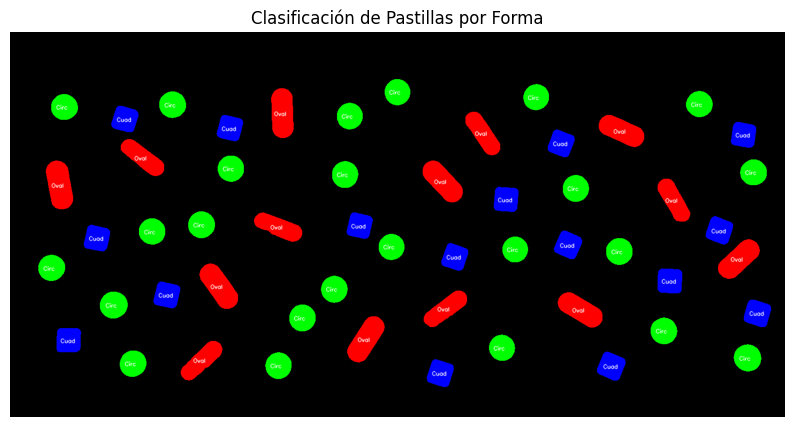

In [16]:
h, w = imagenes_separadas[0].shape
imagen_visualizacion = np.zeros((h, w, 3), dtype = np.uint8)

# Formato BGR
COLOR_REDONDO = (0, 255, 0)  # Verde
COLOR_CUADRADO = (255, 0, 0)  # Azul
COLOR_OVALADO = (0, 0, 255)  # Rojo

# Función auxiliar para pintar y etiquetar la pastilla en la imagen final
def etiquetar_pastilla(img_individual, texto, color):
  # Encontrar el contorno y su centroide (Moments) para saber dónde escribir
  contornos, _ = cv2.findContours(img_individual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if contornos:
    cnt = contornos[0]
    # Dibujar el contorno relleno en la imagen de visualización para ver la pastilla
    cv2.drawContours(imagen_visualizacion, [cnt], -1, color, thickness = -1)
    # Calcular el centro del objeto usando momentos
    M = cv2.moments(cnt)
    if M["m00"] != 0:
      cX = int(M["m10"] / M["m00"])
      cY = int(M["m01"] / M["m00"])
      # Escribir la etiqueta de texto centrada (desplazada un poco a la izquierda y arriba)
      cv2.putText(imagen_visualizacion, texto, (cX - 15, cY + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.35, 
                  (255, 255, 255), 1, cv2.LINE_AA,)

# Procesar y etiquetar cada grupo clasificado
for img in pastillas_redondas:
    etiquetar_pastilla(img, "Circ", COLOR_REDONDO)
for img in pastillas_cuadradas:
    etiquetar_pastilla(img, "Cuad", COLOR_CUADRADO)
for img in pastillas_ovaladas:
    etiquetar_pastilla(img, "Oval", COLOR_OVALADO)

plt.figure(figsize = (10, 10))
imagen_rgb = cv2.cvtColor(imagen_visualizacion, cv2.COLOR_BGR2RGB)
plt.imshow(imagen_rgb)
plt.title("Clasificación de Pastillas por Forma")
plt.axis("off")
plt.show()

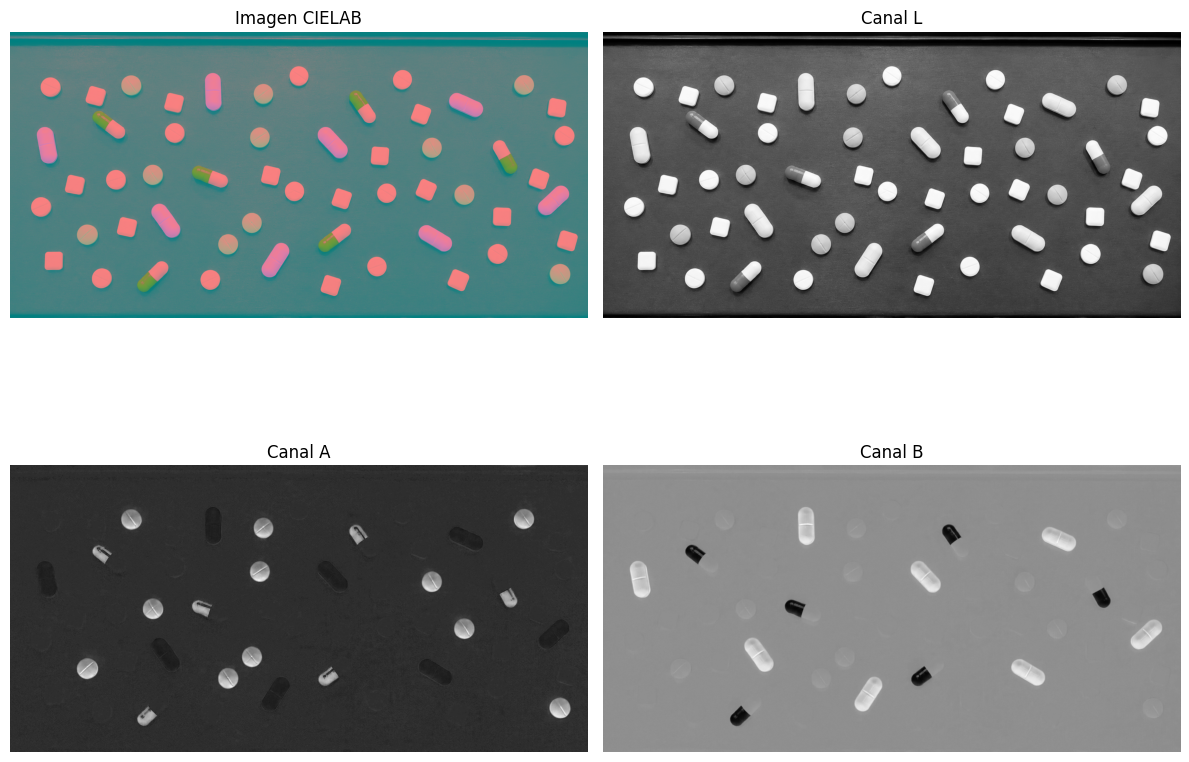

In [17]:
# Intentamos analizar la imagen en el espacio de color CIELAB, que es más perceptualmente uniforme y puede ayudar a diferenciar mejor los colores de las pastillas.

pastillas_ROI_CIELAB = cv2.cvtColor(pastillas_ROI, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(pastillas_ROI_CIELAB)

fig, axs = plt.subplots(2, 2, figsize = (12, 10))
axs = axs.ravel()
titles = ["Imagen CIELAB", "Canal L", "Canal A", "Canal B"]
imagenes = [pastillas_ROI_CIELAB, L, A, B]
for idx, (ax, img, title) in enumerate(zip(axs, imagenes, titles)):
  if idx == 0:
    ax.imshow(img)
  else:
    ax.imshow(img, cmap = "gray")
  ax.set_title(title)
  ax.axis("off")
plt.tight_layout()
plt.show()

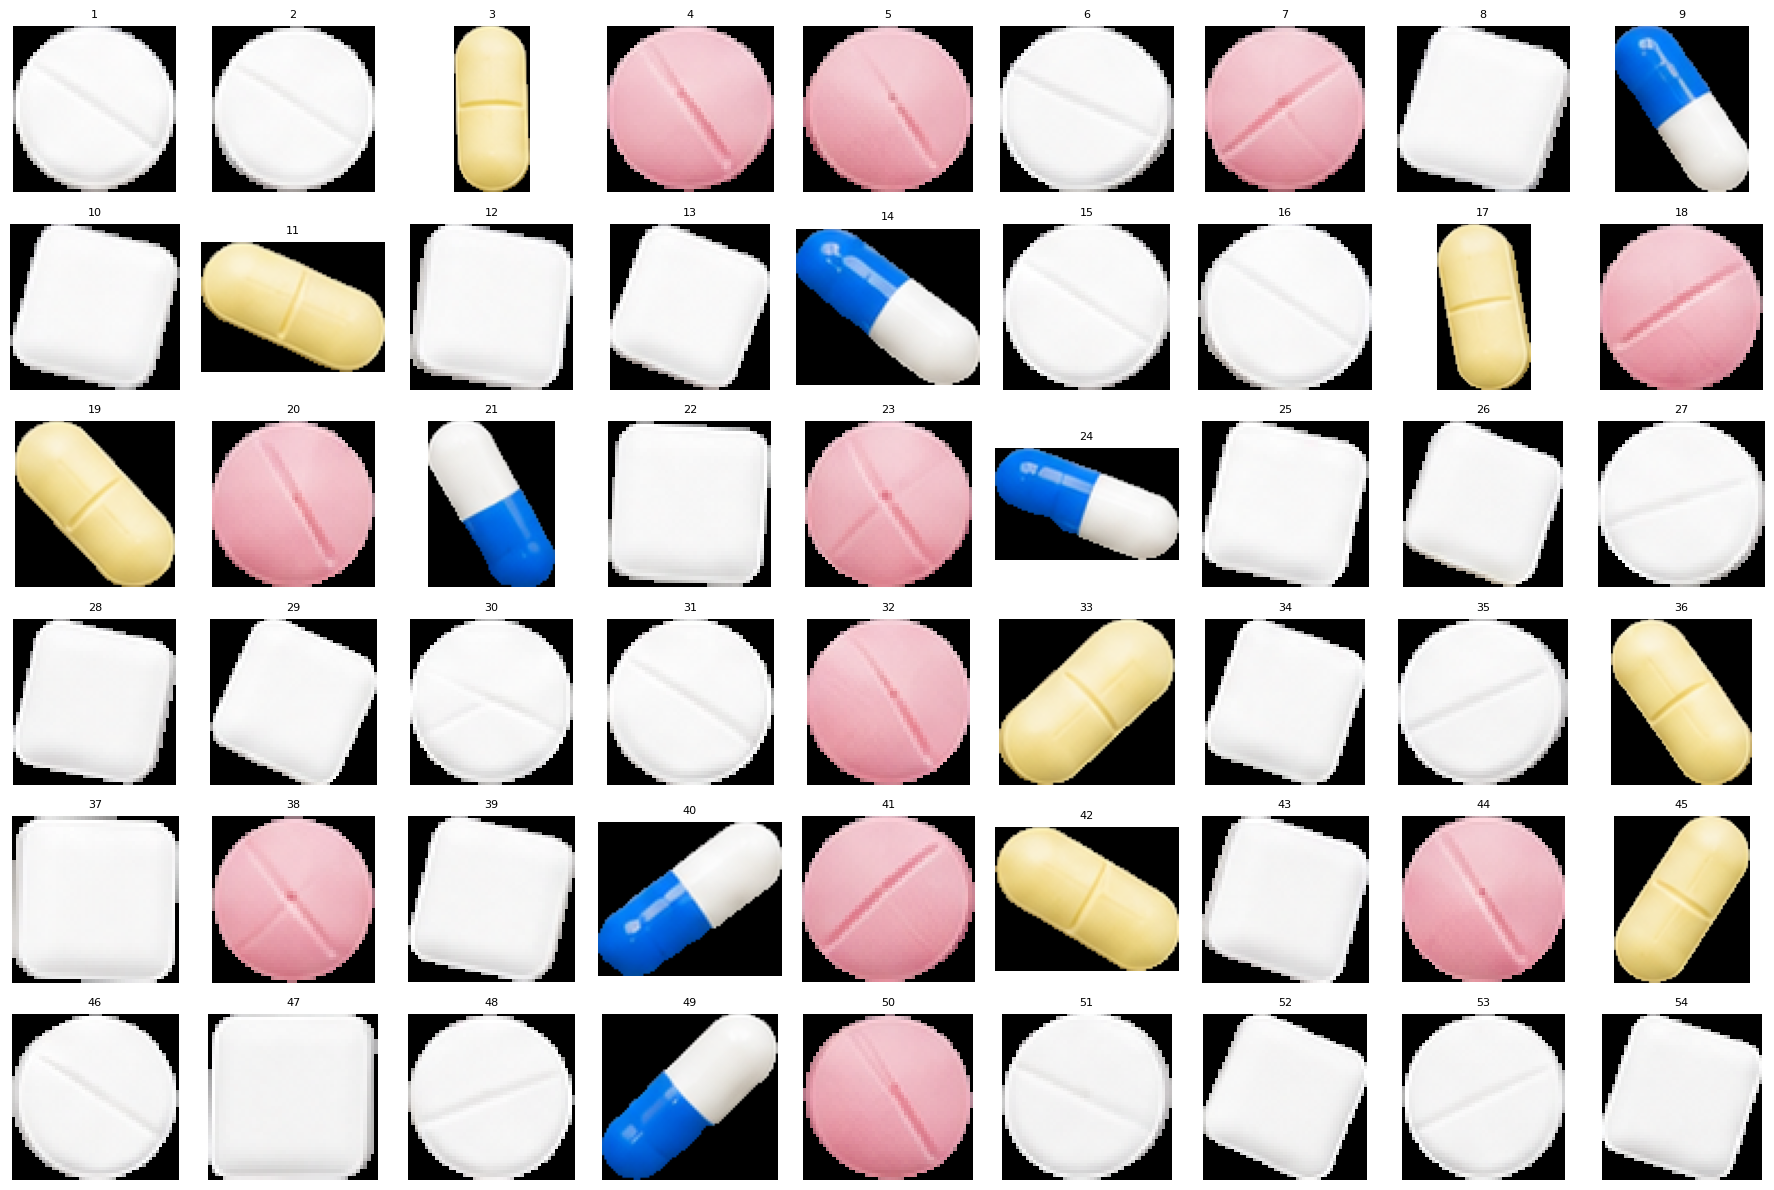

In [18]:
fig, axes = plt.subplots(6, 9, figsize = (18, 12))
axes = axes.ravel()

for i in range(1, num_labels):
  mascara = (labels == i).astype(np.uint8)

  x = stats[i, cv2.CC_STAT_LEFT]
  y = stats[i, cv2.CC_STAT_TOP]
  w = stats[i, cv2.CC_STAT_WIDTH]
  h = stats[i, cv2.CC_STAT_HEIGHT]

  roi_bgr = pastillas_ROI[y:y + h, x:x + w]
  roi_mask = mascara[y:y + h, x:x + w]

  pastilla = cv2.bitwise_and(roi_bgr, roi_bgr, mask = roi_mask)

  axes[i-1].imshow(cv2.cvtColor(pastilla, cv2.COLOR_BGR2RGB)) # Cambiar cv2.COLOR_BGR2RGB si se quiere mostrar en otro espacio de color
  axes[i-1].set_title(f"{i}", fontsize = 8)
  axes[i-1].axis("off")

plt.tight_layout()
plt.show()

Vemos los valores de cada canal para cada pastilla segun su forma para saber qué valores tiene y poder elegir un umbral óptimo.

In [19]:
print("Pastillas Redondas:")
print("ID | L Promedio | a Promedio | b Promedio")
for i, mascara_redondas in enumerate(pastillas_redondas):
  pixeles_redondas = pastillas_ROI_CIELAB[mascara_redondas > 0]
  print(
    f"{i:2d} | "
    f"L={np.mean(pixeles_redondas[:,0]):.1f} | "
    f"a={np.mean(pixeles_redondas[:,1]):.1f} | "
    f"b={np.mean(pixeles_redondas[:,2]):.1f}"
  )

Pastillas Redondas:
ID | L Promedio | a Promedio | b Promedio
 0 | L=242.7 | a=128.1 | b=128.1
 1 | L=243.3 | a=128.1 | b=128.1
 2 | L=200.2 | a=149.3 | b=130.8
 3 | L=196.1 | a=150.9 | b=131.4
 4 | L=241.3 | a=128.2 | b=128.0
 5 | L=198.0 | a=149.5 | b=131.1
 6 | L=243.1 | a=128.1 | b=128.0
 7 | L=243.3 | a=128.2 | b=128.0
 8 | L=196.8 | a=151.1 | b=131.4
 9 | L=197.0 | a=151.1 | b=131.5
10 | L=196.7 | a=150.8 | b=131.6
11 | L=242.4 | a=128.1 | b=128.1
12 | L=243.9 | a=128.1 | b=128.0
13 | L=243.8 | a=128.1 | b=128.1
14 | L=198.1 | a=150.9 | b=131.2
15 | L=240.9 | a=128.2 | b=128.0
16 | L=196.3 | a=151.2 | b=131.4
17 | L=192.1 | a=152.4 | b=131.4
18 | L=195.0 | a=151.8 | b=131.6
19 | L=241.9 | a=128.1 | b=128.1
20 | L=242.2 | a=128.2 | b=128.0
21 | L=190.4 | a=153.4 | b=131.4
22 | L=240.2 | a=128.2 | b=128.0
23 | L=241.2 | a=128.1 | b=128.0


Para las redondas se marcan bien los dos grupos:
* Las blancas tienen valores a≈128 y b≈128
* Las rosas tienen valores a≈149-153 y b≈131

Se puede usar unicamente el valor a para separar correctamente al tener mayor diferencia de valores

In [20]:
print("Pastillas Cuadradas:")
print("ID | L Promedio | a Promedio | b Promedio")
for i, mascara_cuadradas in enumerate(pastillas_cuadradas):
  pixeles_cuadradas = pastillas_ROI_CIELAB[mascara_cuadradas > 0]
  print(
    f"{i:2d} | "
    f"L={np.mean(pixeles_cuadradas[:,0]):.1f} | "
    f"a={np.mean(pixeles_cuadradas[:,1]):.1f} | "
    f"b={np.mean(pixeles_cuadradas[:,2]):.1f}"
  )

Pastillas Cuadradas:
ID | L Promedio | a Promedio | b Promedio
 0 | L=241.4 | a=128.2 | b=127.9
 1 | L=241.9 | a=128.2 | b=128.0
 2 | L=241.7 | a=128.2 | b=128.0
 3 | L=242.2 | a=128.2 | b=128.1
 4 | L=241.7 | a=128.1 | b=128.1
 5 | L=243.3 | a=128.1 | b=128.1
 6 | L=240.9 | a=128.1 | b=128.3
 7 | L=240.6 | a=128.1 | b=128.0
 8 | L=243.1 | a=128.1 | b=128.1
 9 | L=242.3 | a=128.1 | b=128.1
10 | L=242.1 | a=128.1 | b=128.1
11 | L=241.4 | a=128.1 | b=128.1
12 | L=240.4 | a=128.3 | b=128.0
13 | L=239.9 | a=128.1 | b=128.0
14 | L=240.8 | a=128.1 | b=128.1
15 | L=240.4 | a=128.1 | b=128.0


Para las cuadradas todas tienen valores a≈128 y b≈128 por lo que es más facil detectar colores nuevos/desconocidos

In [21]:
print("Pastillas Ovaladas:")
print("ID | L Promedio | a Promedio | b Promedio")
for i, mascara_ovaladas in enumerate(pastillas_ovaladas):
  pixeles_ovaladas = pastillas_ROI_CIELAB[mascara_ovaladas > 0]
  print(
    f"{i:2d} | "
    f"L={np.mean(pixeles_ovaladas[:,0]):.1f} | "
    f"a={np.mean(pixeles_ovaladas[:,1]):.1f} | "
    f"b={np.mean(pixeles_ovaladas[:,2]):.1f}"
  )

Pastillas Ovaladas:
ID | L Promedio | a Promedio | b Promedio
 0 | L=226.0 | a=125.5 | b=159.3
 1 | L=178.1 | a=136.2 | b=98.4
 2 | L=221.6 | a=125.7 | b=160.9
 3 | L=181.5 | a=135.6 | b=100.8
 4 | L=223.8 | a=125.7 | b=160.0
 5 | L=223.7 | a=125.6 | b=160.1
 6 | L=176.5 | a=137.6 | b=97.8
 7 | L=178.9 | a=136.1 | b=99.9
 8 | L=224.4 | a=125.6 | b=158.9
 9 | L=224.6 | a=125.5 | b=160.2
10 | L=177.8 | a=137.3 | b=98.2
11 | L=220.6 | a=125.7 | b=162.7
12 | L=222.6 | a=125.5 | b=161.7
13 | L=176.8 | a=137.1 | b=99.9


Para las ovaladas tambien se marcan bien los grupos
* Las amarillas tienen valores a≈125.5 y b≈159-163
* Las azul/blanco tienen valores a≈136-138 y b≈98-101

Se puede usar unicamente el valor b para separar correctamente al tener mayor diferencia de valores

In [22]:
colores = {
  "blanco": (128, 128),
  "rosa": (151, 131),
  "amarillo": (126, 160),
  "azul_blanco": (137, 99)
}

umbral_desconocido = 15

def clasificador_color(a_prom, b_prom):
  distancias = {}
  for nombre, (a_ref, b_ref) in colores.items():
    distancias[nombre] = np.sqrt((a_prom - a_ref) ** 2 + (b_prom - b_ref) ** 2)
  color = min(distancias, key = distancias.get)
  if distancias[color] > umbral_desconocido:
    return "desconocido"
  return color

In [23]:
datos_pastillas = []

# Redondas
for mascara in pastillas_redondas:
  pixeles = pastillas_ROI_CIELAB[mascara > 0]
  datos_pastillas.append({
    "mascara": mascara,
    "forma": "redonda",
    "L_prom": np.mean(pixeles[:,0]),
    "a_prom": np.mean(pixeles[:,1]),
    "b_prom": np.mean(pixeles[:,2])
  })

# Cuadradas
for mascara in pastillas_cuadradas:
  pixeles = pastillas_ROI_CIELAB[mascara > 0]
  datos_pastillas.append({
    "mascara": mascara,
    "forma": "cuadrada",
    "L_prom": np.mean(pixeles[:,0]),
    "a_prom": np.mean(pixeles[:,1]),
    "b_prom": np.mean(pixeles[:,2])
  })

# Ovaladas
for mascara in pastillas_ovaladas:
  pixeles = pastillas_ROI_CIELAB[mascara > 0]
  datos_pastillas.append({
    "mascara": mascara,
    "forma": "ovalada",
    "L_prom": np.mean(pixeles[:,0]),
    "a_prom": np.mean(pixeles[:,1]),
    "b_prom": np.mean(pixeles[:,2])
  })

In [24]:
redondas_blancas = []
redondas_rosas = []
cuadradas_blancas = []
ovaladas_amarillas = []
ovaladas_azul_blanco = []
desconocidas = []

for dato in datos_pastillas:
  color = clasificador_color(dato["a_prom"], dato["b_prom"])

  if dato["forma"] == "redonda":
    if color == "blanco":
      redondas_blancas.append(dato)
    elif color == "rosa":
      redondas_rosas.append(dato)
    else:
      desconocidas.append(dato)

  elif dato["forma"] == "cuadrada":
    if color == "blanco":
      cuadradas_blancas.append(dato)
    else:
      desconocidas.append(dato)

  elif dato["forma"] == "ovalada":
    if color == "amarillo":
      ovaladas_amarillas.append(dato)
    elif color == "azul_blanco":
      ovaladas_azul_blanco.append(dato)
    else:
      desconocidas.append(dato)

## D. Informar por consola los resultados obtenidos y generar una imagen resultante de la imagen original en donde cada pastilla posea una etiqueta que la identifique según el tipo de pastilla y un id. Por ejemplo, RR1, RR2, .., CB1, CB2, .., etc.

In [25]:
print("Redondas blancas:", len(redondas_blancas))
print("Redondas rosas:", len(redondas_rosas))
print("Cuadradas blancas:", len(cuadradas_blancas))
print("Ovaladas amarillas:", len(ovaladas_amarillas))
print("Ovaladas azul/blanco:", len(ovaladas_azul_blanco))
print("Desconocidas:", len(desconocidas))

Redondas blancas: 13
Redondas rosas: 11
Cuadradas blancas: 16
Ovaladas amarillas: 8
Ovaladas azul/blanco: 6
Desconocidas: 0


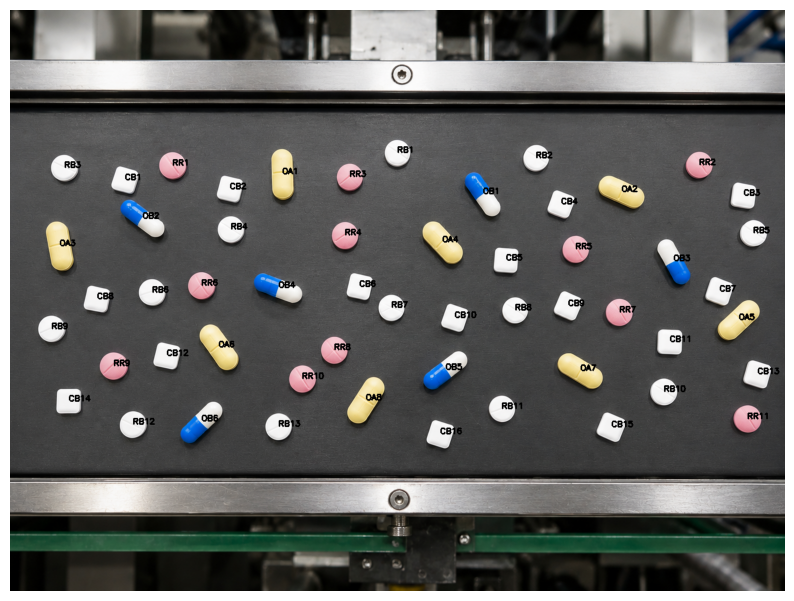

In [26]:
imagen_etiquetada = pastillas.copy()

contador_RB = 1
contador_RR = 1
contador_CB = 1
contador_OA = 1
contador_OB = 1

for dato in redondas_blancas:
  mascara = dato["mascara"]
  cy, cx = np.argwhere(mascara > 0).mean(axis = 0)
  etiqueta = f"RB{contador_RB}"
  contador_RB += 1
  cv2.putText(imagen_etiquetada, etiqueta, (int(cx), int(cy + corte_superior)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

for dato in redondas_rosas:
  mascara = dato["mascara"]
  cy, cx = np.argwhere(mascara > 0).mean(axis = 0)
  etiqueta = f"RR{contador_RR}"
  contador_RR += 1
  cv2.putText(imagen_etiquetada, etiqueta, (int(cx), int(cy + corte_superior)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

for dato in cuadradas_blancas:
  mascara = dato["mascara"]
  cy, cx = np.argwhere(mascara > 0).mean(axis = 0)
  etiqueta = f"CB{contador_CB}"
  contador_CB += 1
  cv2.putText(imagen_etiquetada, etiqueta, (int(cx), int(cy + corte_superior)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

for dato in ovaladas_amarillas:
  mascara = dato["mascara"]
  cy, cx = np.argwhere(mascara > 0).mean(axis = 0)
  etiqueta = f"OA{contador_OA}"
  contador_OA += 1
  cv2.putText(imagen_etiquetada, etiqueta, (int(cx), int(cy + corte_superior)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

for dato in ovaladas_azul_blanco:
  mascara = dato["mascara"]
  cy, cx = np.argwhere(mascara > 0).mean(axis = 0)
  etiqueta = f"OB{contador_OB}"
  contador_OB += 1
  cv2.putText(imagen_etiquetada, etiqueta, (int(cx), int(cy + corte_superior)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(imagen_etiquetada, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 2. Detección de placas patente

Intentaremos detectar los caracteres de la patente antes de la deteccion de la misma.

## A. Segmentar cada uno de los caracteres de la placa patente detectada.

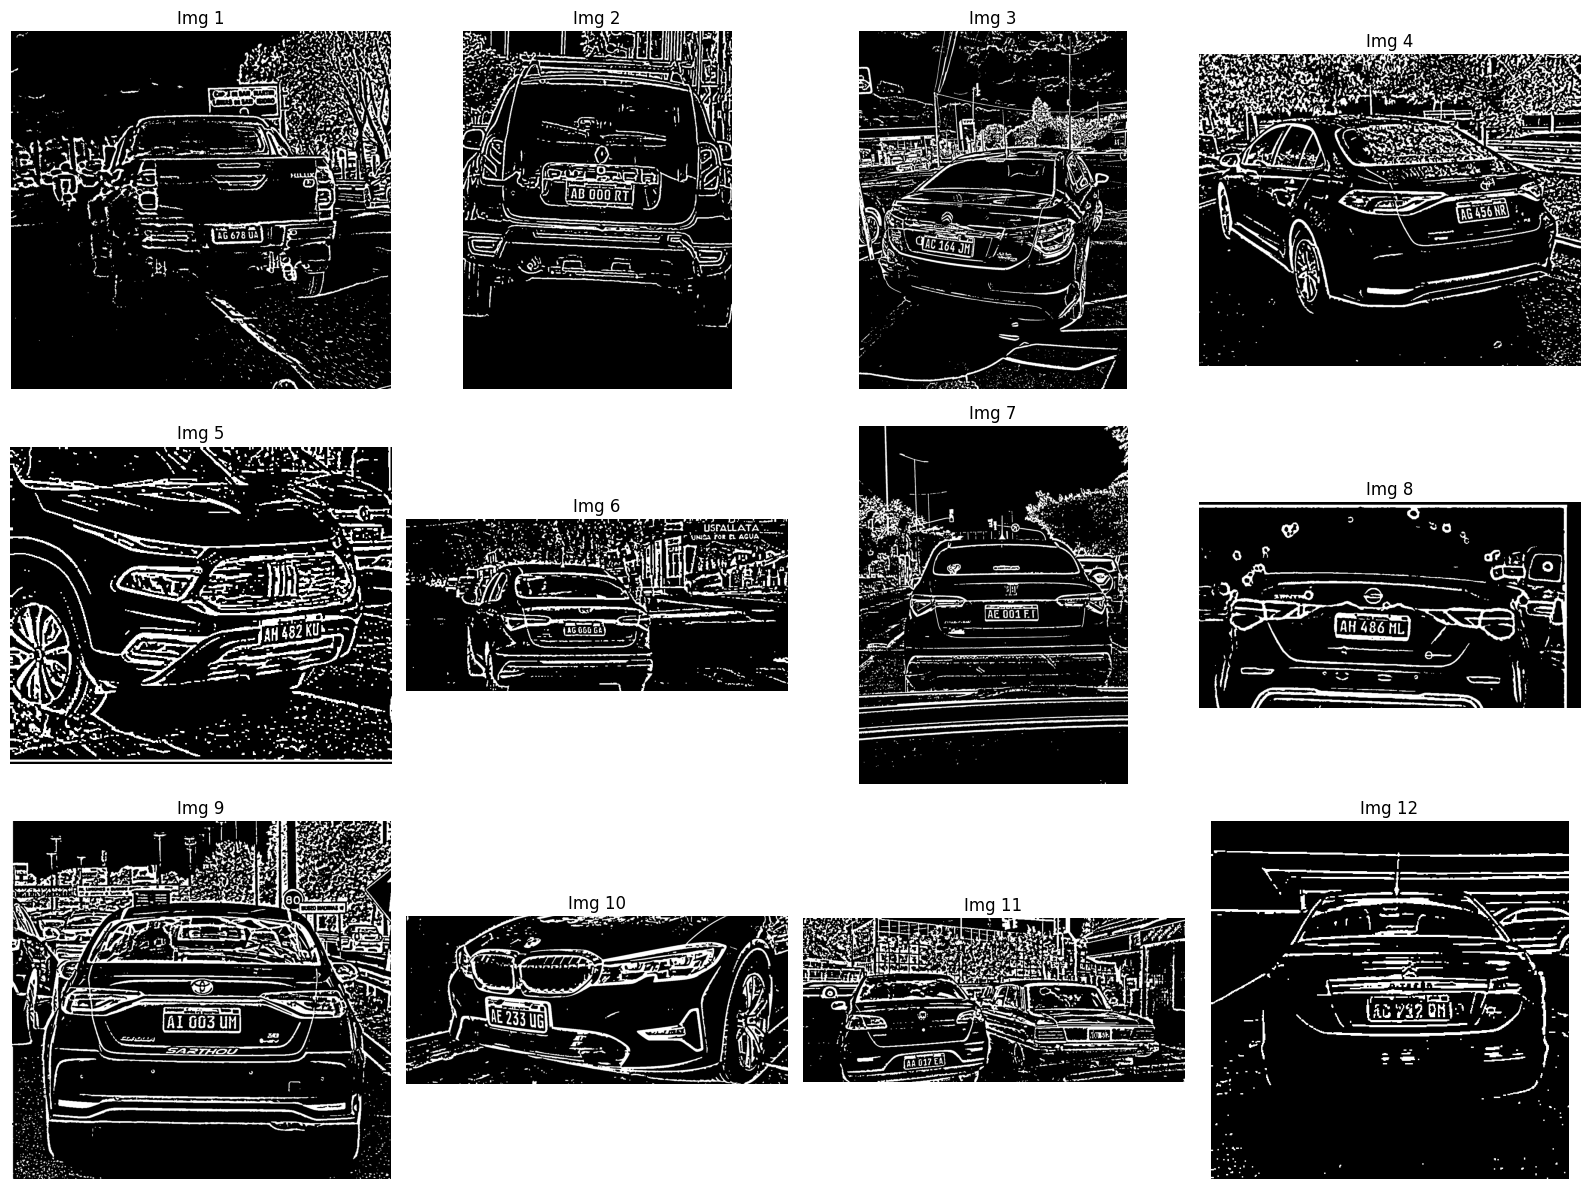

In [27]:
imagenes_patentes = []
for i in range(1, 13):
  path = f"img_{i}.jpg"
  if not os.path.exists(path):
    print(f"No existe: {path}")
    continue
  img = cv2.imread(path)
  if img is None:
    print(f"No se pudo leer: {path}")
    continue
  imagenes_patentes.append(img)

mascaras_patentes = []

for img in imagenes_patentes:
  alto, ancho = img.shape[:2]
  block_size = int(ancho * 0.025) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS (0.015 = 1.5% del ancho de la imagen) Valor optimo encontrado: 0.025
  if block_size % 2 == 0:
    block_size += 1
  if block_size < 3:
    block_size = 3

  kernel_size = max(2, int(ancho * 0.0025)) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS (0.003 = 0.3% del ancho de la imagen) Valor optimo encontrado: 0.0025
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  blur = cv2.GaussianBlur(gray, (3, 3), 0)

  th = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block_size, 7)

  mask_close = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
  mask = cv2.morphologyEx(mask_close, cv2.MORPH_OPEN, kernel)

  mascaras_patentes.append(mask)

fig, axes = plt.subplots(3, 4, figsize = (16, 12))
axes = axes.ravel()
for i, mask in enumerate(mascaras_patentes):
  axes[i].imshow(mask, cmap = 'gray')
  axes[i].set_title(f"Img {i + 1}")
  axes[i].axis("off")

plt.tight_layout()
plt.show()

In [28]:
# COMENTAR TODOS LOS FILTROS APLICADOS

caracteres_por_imagen = []

for idx, (img, mask) in enumerate(zip(imagenes_patentes, mascaras_patentes)):
  alto, ancho = img.shape[:2]
  
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
  
  min_w = max(3, int(ancho * 0.006)) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS (0.004 = 0.4% del ancho de la imagen) Valor optimo encontrado: 0.006
  min_h = max(3, int(alto * 0.015)) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS
  min_area = min_w * min_h
  max_w = max(3, int(ancho * 0.03)) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS
  max_h = max(3, int(alto * 0.09)) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS
  max_area = max_w * max_h

  cajas_candidatas = []
  for i in range(1, num_labels):
    bx = stats[i, cv2.CC_STAT_LEFT]
    by = stats[i, cv2.CC_STAT_TOP]
    bw = stats[i, cv2.CC_STAT_WIDTH]
    bh = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    if bw > min_w and bh > min_h and area > min_area and bw < max_w and bh < max_h and area < max_area:
      if bh >= bw:
        ratio = bh / bw 
        if 1.09 <= ratio <= 4.65: # IR AJUSTANDO ESTOS VALORES PARA MEJORAR RESULTADOS
          cajas_candidatas.append([bx, by, bw, bh])

  cajas_candidatas = sorted(cajas_candidatas, key = lambda x: x)

  cajas_limpias = []
  for caja in cajas_candidatas:
    bx, by, bw, bh = caja
    duplicada = False
    for i, c_limpia in enumerate(cajas_limpias):
      lx, ly, lw, lh = c_limpia
      interseccion_x = max(0, min(bx + bw, lx + lw) - max(bx, lx))
      overlap_ratio = interseccion_x / min(bw, lw)
      if overlap_ratio > 0.5 and abs(by - ly) < max(bh, lh) * 0.5: # IR AJUSTANDO ESTOS VALORES PARA MEJORAR RESULTADOS
        duplicada = True
        if bh > lh:
          cajas_limpias[i] = caja
        break
    if not duplicada:
      cajas_limpias.append(caja)

  grupos = []
  max_dist_x = max(5, int(ancho * 0.02)) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS
  max_desv_y = max(5, int(alto * 0.025)) # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS

  for caja in cajas_limpias:
    bx, by, bw, bh = caja
    asignado = False
    
    for grupo in grupos:
      bx_v, by_v, bw_v, bh_v = grupo[-1]
      dist_x = bx - (bx_v + bw_v)
      desv_y = abs(by - by_v)
      if -5 <= dist_x <= max_dist_x and desv_y <= max_desv_y:
        grupo.append(caja)
        asignado = True
        break
        
    if not asignado:
      grupos.append([caja])

  grupo_ganador = []
  mejor_score = -999999

  for grupo in grupos:
    if 7 <= len(grupo) <= 11: # IR AJUSTANDO ESTOS VALORES PARA MEJORAR RESULTADOS
      anchos = [c[2] for c in grupo]
      alturas = [c[3] for c in grupo]
      
      median_w = np.median(anchos)
      median_h = np.median(alturas)
      
      grupo_filtrado = []
      for c in grupo:
        if 0.35 <= c[2] / median_w <= 1.8 and 0.6 <= c[3] / median_h <= 1.2: # IR AJUSTANDO ESTOS VALORES PARA MEJORAR RESULTADOS
          grupo_filtrado.append(c)
          
      if len(grupo_filtrado) < 5:
        continue
        
      dists_x = []
      for k in range(len(grupo_filtrado) - 1):
        dists_x.append(max(0, grupo_filtrado[k + 1][0] - (grupo_filtrado[k][0] + grupo_filtrado[k][2])))
        
      var_w = np.var([c[2] for c in grupo_filtrado]) if len(grupo_filtrado) > 1 else 999
      var_dists = np.var(dists_x) if len(dists_x) > 1 else 999
      
      score = len(grupo_filtrado) * 100 - (var_w * 2 + var_dists)
      if score > mejor_score:
        mejor_score = score
        grupo_ganador = grupo_filtrado

  grupo_ganador = sorted(grupo_ganador, key = lambda x: x[0])

  if len(grupo_ganador) > 7:
    dists_consecutivas = []
    for k in range(len(grupo_ganador) - 1):
      dists_consecutivas.append(grupo_ganador[k + 1][0] - (grupo_ganador[k][0] + grupo_ganador[k][2]))
    
    mediana_dist = np.median(dists_consecutivas)
    cajas_filtradas_arbitro = [grupo_ganador[0]]
    
    for k in range(len(dists_consecutivas)):
      if dists_consecutivas[k] <= mediana_dist * 3.5: # IR AJUSTANDO ESTE VALOR PARA MEJORAR RESULTADOS
        cajas_filtradas_arbitro.append(grupo_ganador[k + 1])
      else:
        if len(cajas_filtradas_arbitro) >= 6:
          break
        else:
          cajas_filtradas_arbitro = [grupo_ganador[k + 1]]
          
    grupo_ganador = cajas_filtradas_arbitro

  caracteres_por_imagen.append(grupo_ganador)

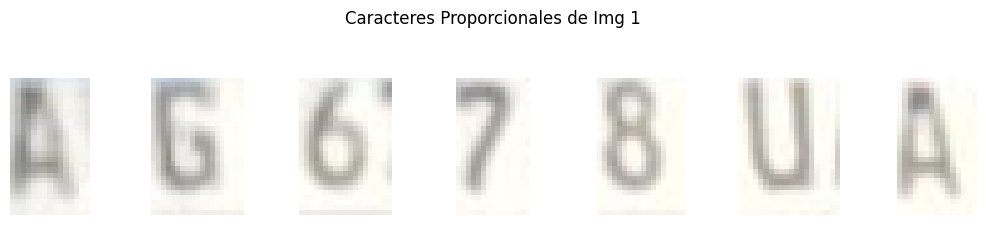

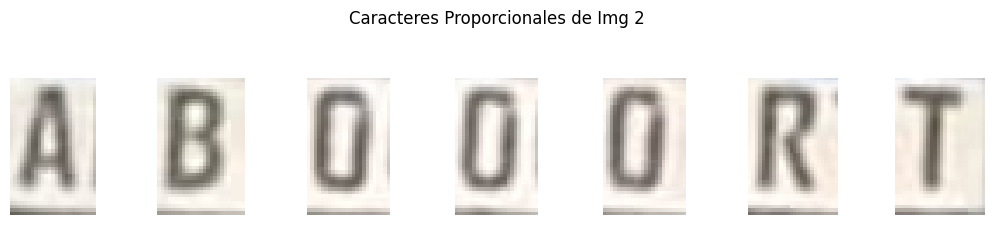

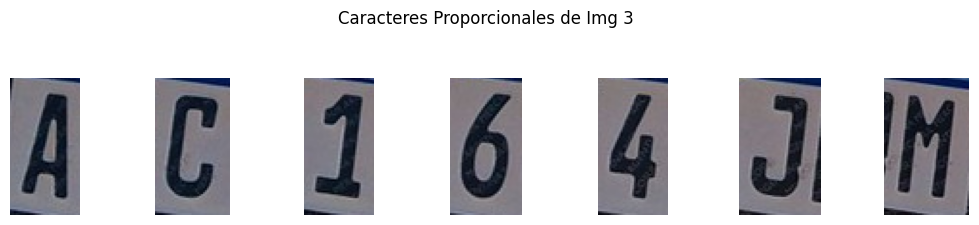

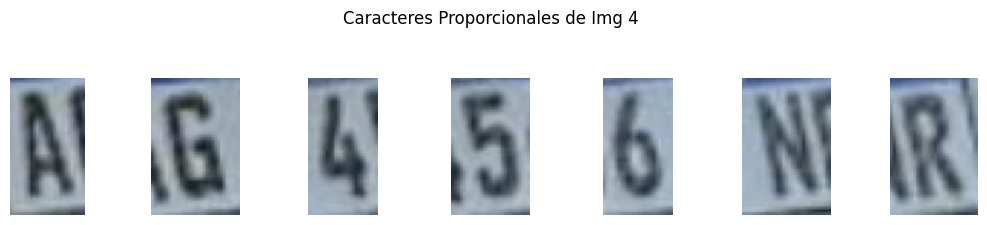

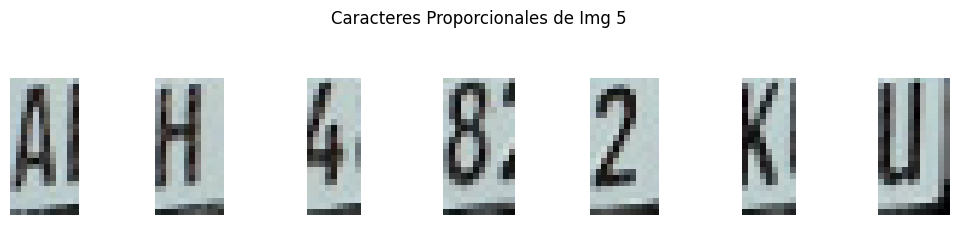

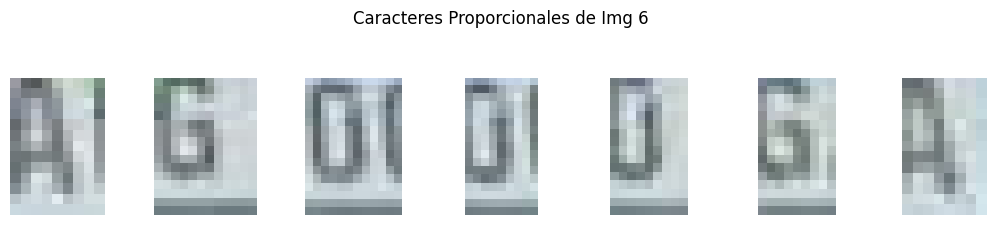

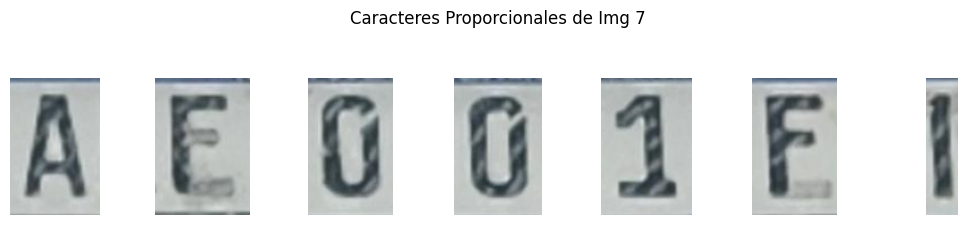

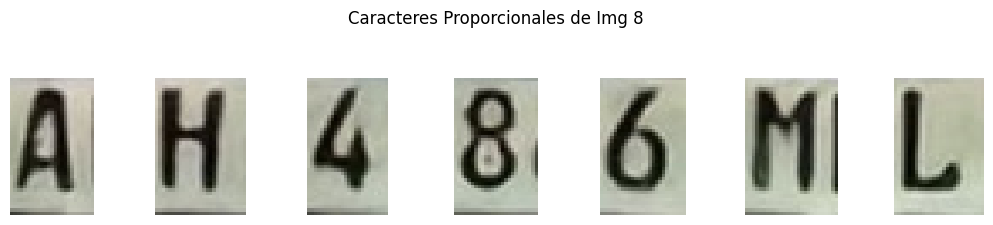

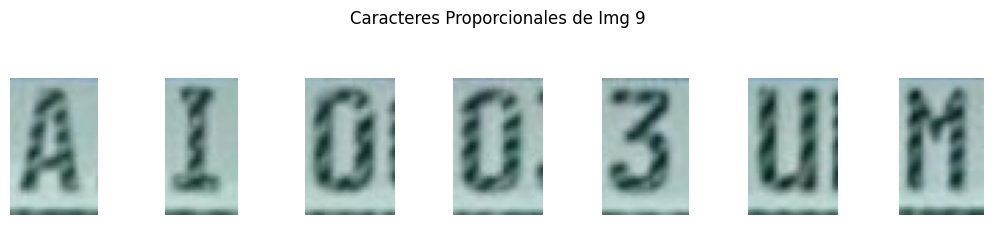

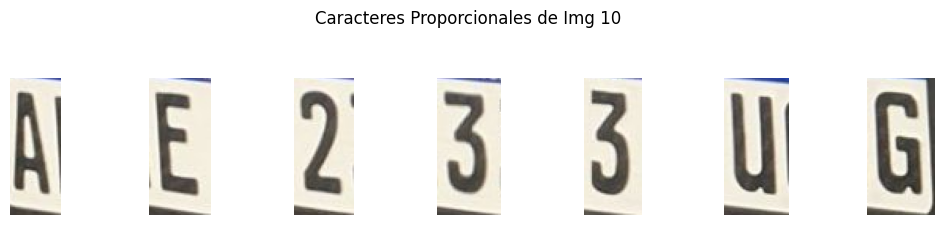

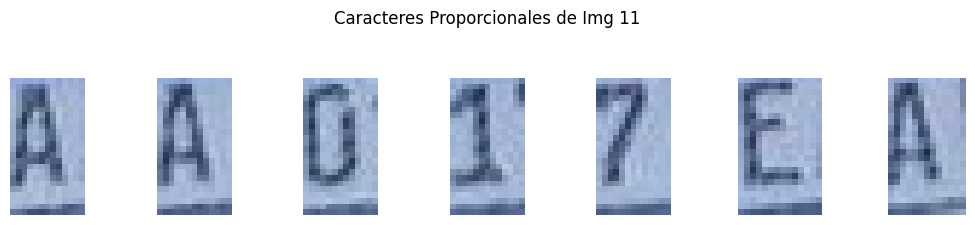

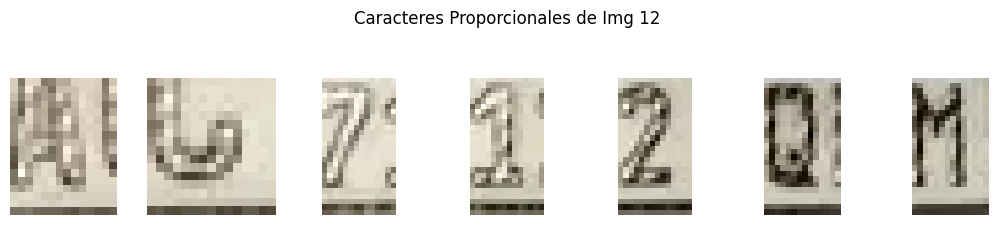

In [29]:
for idx, (img, grupo_ganador) in enumerate(zip(imagenes_patentes, caracteres_por_imagen)):
  alto, ancho = img.shape[:2]
  
  if len(grupo_ganador) > 0:
    fig_char, axes_char = plt.subplots(1, len(grupo_ganador), figsize = (len(grupo_ganador) * 1.5, 2))
    fig_char.suptitle(f"Caracteres Proporcionales de Img {idx + 1}", fontsize = 12, y = 1.1)
    
    if len(grupo_ganador) == 1:
      axes_char = [axes_char]
      
    for c_idx, (bx, by, bw, bh) in enumerate(grupo_ganador):
      margen_dinamico_x = int(bw * 0.25) # IR AJUSTANDO ESTE VALOR PARA MEJORAR VISUALIZACIONES
      margen_dinamico_y = int(bh * 0.18) # IR AJUSTANDO ESTE VALOR PARA MEJORAR VISUALIZACIONES
      
      cx_min = max(0, bx - margen_dinamico_x)
      cx_max = min(ancho, bx + bw + margen_dinamico_x)
      cy_min = max(0, by - margen_dinamico_y)
      cy_max = min(alto, by + bh + margen_dinamico_y)
      
      crop_letra = img[cy_min:cy_max, cx_min:cx_max]
      crop_rgb = cv2.cvtColor(crop_letra, cv2.COLOR_BGR2RGB)
      
      axes_char[c_idx].imshow(crop_rgb)
      axes_char[c_idx].axis("off")
      
    plt.tight_layout()
    plt.show()

## B. Detectar y segmentar la placa patente presente.

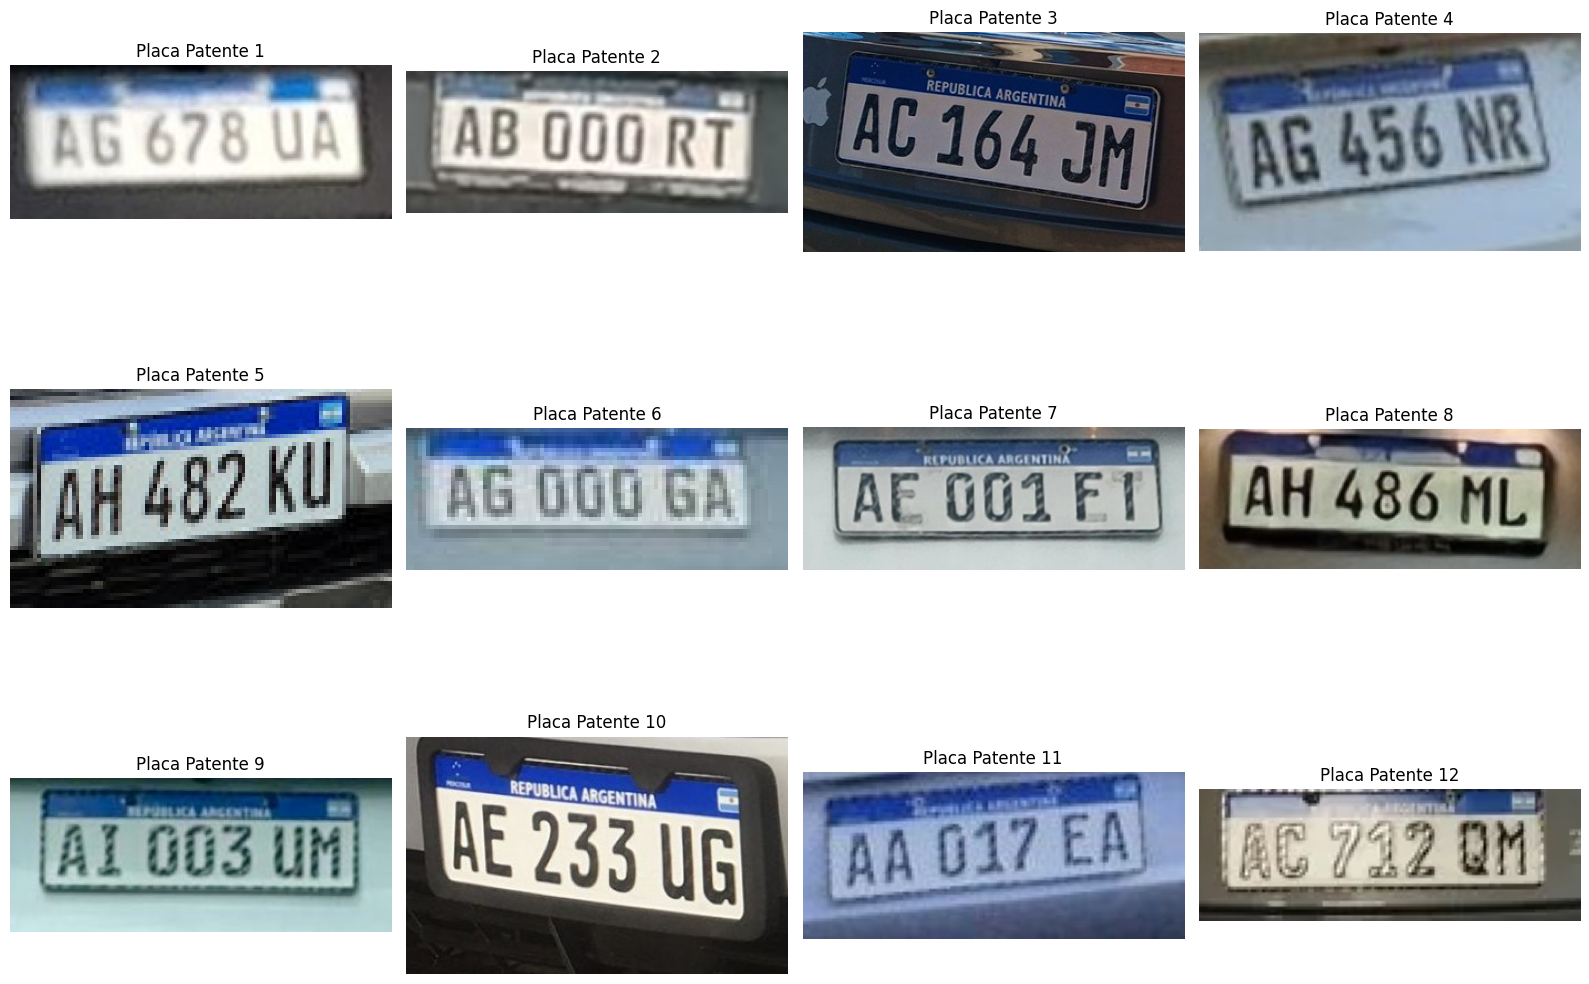

In [30]:
recortes_patentes_finales = []

for idx, (img, grupo_ganador) in enumerate(zip(imagenes_patentes, caracteres_por_imagen)):
  alto, ancho = img.shape[:2]
  
  if len(grupo_ganador) > 0:
    grupo_ganador = sorted(grupo_ganador, key = lambda x: x[0])
    
    px_min = grupo_ganador[0][0]
    px_max = grupo_ganador[-1][0] + grupo_ganador[-1][2]
    
    todas_las_y = [c[1] for c in grupo_ganador]
    todas_las_h = [c[3] for c in grupo_ganador]
    
    py_min = min(todas_las_y)
    py_max = max([y + h for y, h in zip(todas_las_y, todas_las_h)])
    
    ancho_letras = px_max - px_min
    alto_letras = py_max - py_min
    
    y_primera = grupo_ganador[0][1] + (grupo_ganador[0][3] / 2)
    y_ultima = grupo_ganador[-1][1] + (grupo_ganador[-1][3] / 2)
    desnivel_vertical = abs(y_ultima - y_primera)
    
    factor_margen_x = 0.18 # IR AJUSTANDO ESTE VALOR PARA MEJORAR VISUALIZACIONES
    
    if desnivel_vertical > (alto_letras * 0.15):
      factor_margen_y = 0.65 # IR AJUSTANDO ESTE VALOR PARA MEJORAR VISUALIZACIONES
    else:
      factor_margen_y = 0.9 # IR AJUSTANDO ESTE VALOR PARA MEJORAR VISUALIZACIONES
      
    margen_dinamico_x = int(ancho_letras * factor_margen_x)
    margen_dinamico_y = int(alto_letras * factor_margen_y)
    
    plat_xmin = max(0, px_min - margen_dinamico_x)
    plat_xmax = min(ancho, px_max + margen_dinamico_x)
    plat_ymin = max(0, py_min - margen_dinamico_y)
    plat_ymax = min(alto, py_max + margen_dinamico_y)
    
    crop_placa = img[plat_ymin:plat_ymax, plat_xmin:plat_xmax]
    recortes_patentes_finales.append(crop_placa)
  else:
    recortes_patentes_finales.append(np.zeros((100, 300, 3), dtype = np.uint8))

fig, axes = plt.subplots(3, 4, figsize = (16, 12))
axes = axes.ravel()

for i, img_result in enumerate(recortes_patentes_finales):
  img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
  axes[i].imshow(img_rgb)
  axes[i].set_title(f"Placa Patente {i+1}")
  axes[i].axis("off")

plt.tight_layout()
plt.show()